# Population Dynamics

This notebook illustrates some models defined by the first two sections of the book *Mathematical Biology I. An Introduction* by J.D. Murray, 3rd edition, Springer-Verlag 2002.

In [1]:
using Plots

In [2]:
using SymPy

In [3]:
using DifferentialEquations

## 1. Modeling Population Growth

A differential equation to model the growth of a population was proposed by Verhulst in the 19th century.  We use the following notation.

* Let $N(t)$ be the number of the population in function of time $t$.

* The carrying capacity is $K$.

* The birth rate is $r$.

In [4]:
r, K, t = Sym("r, K, t")

(r, K, t)

In [5]:
N = SymFunction("N")

N

In [6]:
verhulst = Eq(diff(N(t),t), r*N(t)*(1-N(t)/K))

d            /    N(t)\     
--(N(t)) = r*|1 - ----|*N(t)
dt           \     K  /     

The rate of increase is proportional to the birth rate times the population number, multiplied with a term that becomes smaller and smaller as the population number approaches the carrying capacity.

We will solve this model symbolically, using $N_0$ for the initial condition.

In [7]:
N0 = Sym("N0")
initconds = Dict(N(0) => N0)

Dict{Sym{PyCall.PyObject}, Sym{PyCall.PyObject}} with 1 entry:
  N(0) => N0

In [8]:
growth = dsolve(verhulst, ics=initconds)

                    r*t        
             -K*N0*e           
N(t) = ------------------------
                /      r*t    \
                |  N0*e       |
       (K - N0)*|- ------- - 1|
                \   K - N0    /

For a numerical example, take $K = 50$, $N_0 = 8$ and $r = 0.7$.

In [9]:
population = subs(growth.rhs(), K=> 50, N0 => 8, r => 0.7)

          0.7*t    
    -200*e         
-------------------
   /     0.7*t    \
   |  4*e         |
21*|- -------- - 1|
   \     21       /

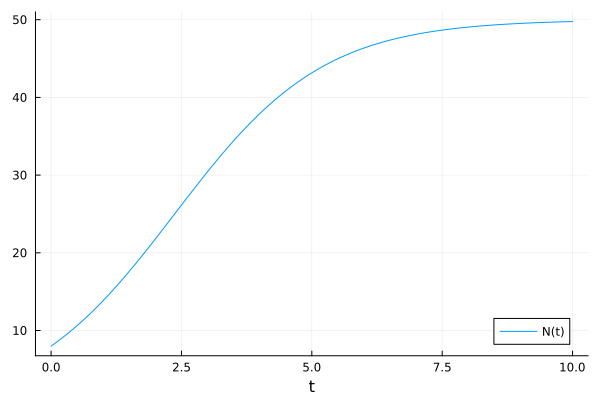

In [10]:
plot(0:0.01:10, population, xlabel = "t", label="N(t)", legend=:bottomright)

Observe the leveling off towards the carrying capacity as $t$ increases.

In [11]:
# savefig("figverhulst.png")

## 2. Population Growth with Predator

We consider the population dynamics of the spruce budworm.  Birds eat worms.

### 2.1 Logistic Growh with Predator Term

The same logistic growth model applies, but we subtract a predator term.  This predator term is a function of the size of the population.  Using the same symbols as in the above model, we add a new symbolic function ``P``.

In [12]:
P = SymFunction("P")

P

In [13]:
worm = Eq(diff(N(t), t), r*N(t)*(1-N(t)/K) - P(N(t)))

d            /    N(t)\               
--(N(t)) = r*|1 - ----|*N(t) - P(N(t))
dt           \     K  /               

*What would be a good model for P?*

The population of the worms should reach some critical value before the birds start noticing the worms.  Once this happens, the birds eat worms in greater numbers.  Once the population falls below another critical value, the predation disappears.

In [14]:
A, B, n = Sym("A, B, n")
p = B*n^2/(A^2 + n^2)

     2 
  B*n  
-------
 2    2
A  + n 

In [15]:
shape = subs(p, A => 30, B => 4)

     2  
  4*n   
--------
 2      
n  + 900

To plot, we make a function out of the symbolic expression.

In [16]:
shapefun(x) = subs(shape, n=>x)

shapefun (generic function with 1 method)

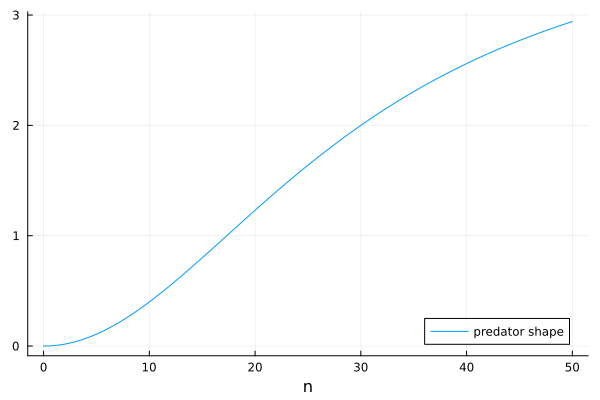

In [17]:
plot(0:0.01:50, shapefun, xlabel="n", label="predator shape", legend=:bottomright)

In [18]:
# savefig("figwormpredatorshape.png")

For $n \approx 10$, the predator term is still rather slow, it only starts to pick up when $n$ approaches 20, and then it starts to level off after 30.

In [19]:
pnt = subs(p, n=>N(t))

    2     
 B*N (t)  
----------
 2    2   
A  + N (t)

In [20]:
wormode = subs(worm, P(N(t)) => pnt)

                 2                         
d             B*N (t)       /    N(t)\     
--(N(t)) = - ---------- + r*|1 - ----|*N(t)
dt            2    2        \     K  /     
             A  + N (t)                    

The problem with the above equation is that it has too many parameters.

### 2.2 Nondimensional Terms

To study the model, we have to introduce nondimensional terms.

Consider the following substitutions:

$$
   N(t) = A u(t), \quad r = \frac{B r}{A}, \quad K = q A
$$

In [21]:
q = Sym("q")
u = SymFunction("u")
wormode1 = subs(wormode, N(t) => A*u(t), r => B*r/A, K => q*A)

                  2    2                          
d                A *B*u (t)        /    u(t)\     
--(A*u(t)) = - ------------- + B*r*|1 - ----|*u(t)
dt              2  2       2       \     q  /     
               A *u (t) + A                       

In [22]:
simplify(wormode1)

               /                       / 2       \\     
  d          B*\-q*u(t) + r*(q - u(t))*\u (t) + 1//*u(t)
A*--(u(t)) = -------------------------------------------
  dt                          / 2       \               
                            q*\u (t) + 1/               

Observe that the $A$ no longer appears in the right hand side.

We can make the $B$ appear to the left by the following substitution:

$$
   u(t) = u(tB/A).
$$

In [23]:
wormode2 = subs(wormode1, u(t) => u(t*B/A))

                    2    2/B*t\        /     /B*t\\       
                   A *B*u |---|        |    u|---||       
d /   /B*t\\              \ A /        |     \ A /|  /B*t\
--|A*u|---|| = - --------------- + B*r*|1 - ------|*u|---|
dt\   \ A //      2  2/B*t\    2       \      q   /  \ A /
                 A *u |---| + A                           
                      \ A /                               

In the first term of the right hand side, the $A^2$ will drop out.

The ``cancel()`` command will remove the $A^2$, but applying the ``cancel()`` to the entire expression brings the whole expression on a common denominator and we do not want to do this.

In [24]:
wormode2rhs = wormode2.rhs()

     2    2/B*t\        /     /B*t\\       
    A *B*u |---|        |    u|---||       
           \ A /        |     \ A /|  /B*t\
- --------------- + B*r*|1 - ------|*u|---|
   2  2/B*t\    2       \      q   /  \ A /
  A *u |---| + A                           
       \ A /                               

In [25]:
wormode2newrhs = cancel(wormode2rhs.args[2]) + wormode2rhs.args[1]

    /     /B*t\\              2/B*t\ 
    |    u|---||           B*u |---| 
    |     \ A /|  /B*t\        \ A / 
B*r*|1 - ------|*u|---| - -----------
    \      q   /  \ A /    2/B*t\    
                          u |---| + 1
                            \ A /    

In [26]:
wormode2newlhs = simplify(wormode2.lhs())

  /  d           \|        
B*|-----(u(xi_1))||     B*t
  \dxi_1         /|xi_1=---
                         A 

In [27]:
wormode3 = Eq(wormode2newlhs, wormode2newrhs)

                                  /     /B*t\\              2/B*t\ 
                                  |    u|---||           B*u |---| 
  /  d           \|               |     \ A /|  /B*t\        \ A / 
B*|-----(u(xi_1))||     B*t = B*r*|1 - ------|*u|---| - -----------
  \dxi_1         /|xi_1=---       \      q   /  \ A /    2/B*t\    
                         A                              u |---| + 1
                                                          \ A /    

We see that the $B$ now appears at the left and at the right of the equation.

The last substitution is

$$
    \frac{B t}{A} = t.
$$

In [28]:
wormode4 = subs(wormode3, t*B/A=>t)

                                                      2    
  /  d           \|             /    u(t)\         B*u (t) 
B*|-----(u(xi_1))||       = B*r*|1 - ----|*u(t) - ---------
  \dxi_1         /|xi_1=t       \     q  /         2       
                                                  u (t) + 1

In [29]:
wormode4rhs = wormode4.rhs()
rightside = wormode4rhs.args[1]/B + wormode4rhs.args[2]/B

                       2     
  /    u(t)\          u (t)  
r*|1 - ----|*u(t) - ---------
  \     q  /         2       
                    u (t) + 1

In [30]:
modelworm = Eq(diff(u(t),t), rightside)

                                  2     
d            /    u(t)\          u (t)  
--(u(t)) = r*|1 - ----|*u(t) - ---------
dt           \     q  /         2       
                               u (t) + 1

### 2.3 steady states

If we look for steady states, then we look for zeros of the right hand side in the model.

In [31]:
f = modelworm.rhs()

                       2     
  /    u(t)\          u (t)  
r*|1 - ----|*u(t) - ---------
  \     q  /         2       
                    u (t) + 1

Observe that $u(t)$ is a common factor, so $u(t) = 0$ is a steady state.

Now we divide out the $u(t)$ common factor.

In [32]:
x = Sym("x")
fx = subs(f, u(t) => x)

                 2  
    /    x\     x   
r*x*|1 - -| - ------
    \    q/    2    
              x  + 1

In [33]:
g = fx.args[1]/x + fx.args[2]/x

  /    x\     x   
r*|1 - -| - ------
  \    q/    2    
            x  + 1

Let us consider the two terms separately.

In [34]:
h1, h2 = g.args[1], -g.args[2]

(r*(1 - x/q), x/(x^2 + 1))

Let us make a plot for $r = 0.4$ and $q = 20$.

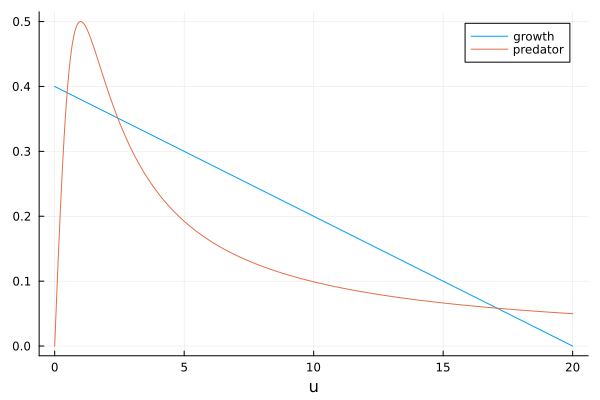

In [35]:
h1fun(xv) = subs(h1, r=>0.4, q => 20, x => xv)
h2fun(xv) = subs(h2, r=>0.4, q => 20, x => xv)
plot(0:0.01:20, h1fun, xlabel="u", label="growth")
steady = plot!(0:0.01:20, h2fun, xlabel="u", label="predator")

In [36]:
# savefig("figwormsteadystates.png")

We see there are three steady states, for our particular choices of the parameters.

In [37]:
h1e = subs(h1, r=>0.4, q=>20)

0.4 - 0.02*x

In [38]:
h2e = subs(h2, r=>0.4, q=>20)

  x   
------
 2    
x  + 1

In [39]:
states = solve(h1e - h2e)

3-element Vector{Sym{PyCall.PyObject}}:
 0.480535939911864 - 0.e-22*I
  2.43633300316055 + 0.e-19*I
  17.0831310569276 - 0.e-20*I

### 2.4 a numerical solution

Let us solve the model for $r = 0.4$ and $q = 20$.

In [40]:
specialworm = subs(modelworm, r=>0.4, q=>20)

                                    2     
d              /    u(t)\          u (t)  
--(u(t)) = 0.4*|1 - ----|*u(t) - ---------
dt             \     20 /         2       
                                 u (t) + 1

In [41]:
initconds = Dict(u(0)=>2.4)

Dict{Sym{PyCall.PyObject}, Float64} with 1 entry:
  u(0) => 2.4

In [42]:
# dsolve(specialworm, ics=initconds)

In [43]:
"""
    function wormrhs!(du, u, p, t)

defines the right hand side for a special worm model.
"""
function wormrhs!(du, u, p, t)
    growth = 0.4*(1 - u[1]/20)*u[1]
    predator = - (u[1]^2)/(u[1]^2 + 1)
    du[1] = growth + predator
end

wormrhs!

The initial condition is very close to one of the steady states.

In [44]:
timespan = (0,60)
specialode = ODEProblem(wormrhs!, [2.4], timespan)

ODEProblem with uType Vector{Float64} and tType Int64. In-place: true
Non-trivial mass matrix: false
timespan: (0, 60)
u0: 1-element Vector{Float64}:
 2.4

In [45]:
sol = solve(specialode)

retcode: Success
Interpolation: 3rd order Hermite
t: 16-element Vector{Float64}:
  0.0
  0.31897711989271615
  2.237843989683818
  5.551622669135096
  9.311273749300323
 13.612277037028647
 17.985145920073556
 22.00178332611892
 25.89962303634802
 29.973308270533103
 34.23673690349549
 38.77841810292171
 43.99075402473218
 49.990351665923825
 57.209381675500865
 60.0
u: 16-element Vector{Vector{Float64}}:
 [2.4]
 [2.397605557721931]
 [2.379513317580878]
 [2.3265821202910284]
 [2.207267410226695]
 [1.9236030662024972]
 [1.3982630928222008]
 [0.8803578193895758]
 [0.6234532742437225]
 [0.5291477324862351]
 [0.4967117694050077]
 [0.48562067701074185]
 [0.4818959015294326]
 [0.48083779415279587]
 [0.48058815568732133]
 [0.48056167631705604]

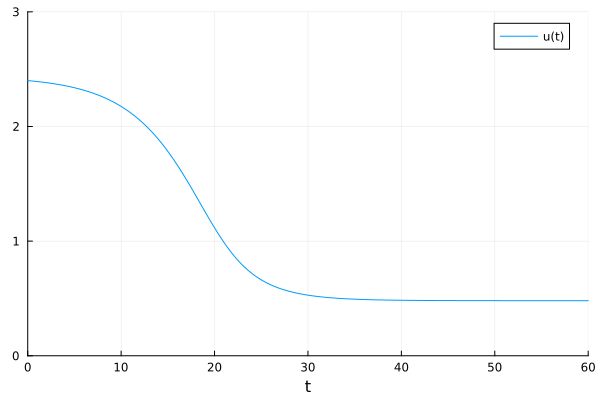

In [46]:
plot(sol, xaxis="t", label="u(t)", ylims=(0, 3))

In [47]:
timespan = (0,60)
specialode2 = ODEProblem(wormrhs!, [2.5], timespan)

ODEProblem with uType Vector{Float64} and tType Int64. In-place: true
Non-trivial mass matrix: false
timespan: (0, 60)
u0: 1-element Vector{Float64}:
 2.5

In [48]:
sol = solve(specialode2)

retcode: Success
Interpolation: 3rd order Hermite
t: 16-element Vector{Float64}:
  0.0
  0.2866131316171784
  1.990727861457347
  4.9208145089890385
  8.244419273201144
 12.054422848318614
 16.018100986614837
 20.04250576431782
 24.116308228059502
 29.256388110440625
 33.676089850206935
 38.270874399334716
 43.02881198891913
 48.65370625977381
 55.16319562318488
 60.0
u: 16-element Vector{Vector{Float64}}:
 [2.5]
 [2.5038172166814414]
 [2.5318018896240835]
 [2.6103411574010797]
 [2.783272202979122]
 [3.215359350317428]
 [4.273420213451318]
 [6.64177725017979]
 [10.486311259790932]
 [14.701601160374006]
 [16.31054397672816]
 [16.86390545909046]
 [17.02528926301582]
 [17.07106531595257]
 [17.081061166963014]
 [17.082602439595316]

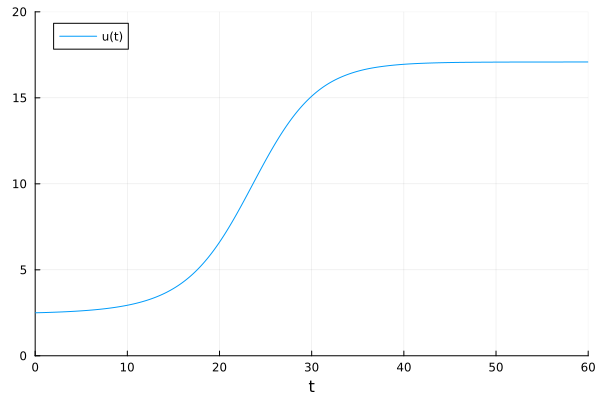

In [49]:
plot(sol, xaxis="t", label="u(t)", ylims=(0, 20))

In [50]:
# savefig("figwormspecial.png")

Even though we started very close to one of the steady states, we ended up at another steady states.

### 2.5 catatrophic jumps and hysteresis

Consider again the plot with the growth and the predator term.

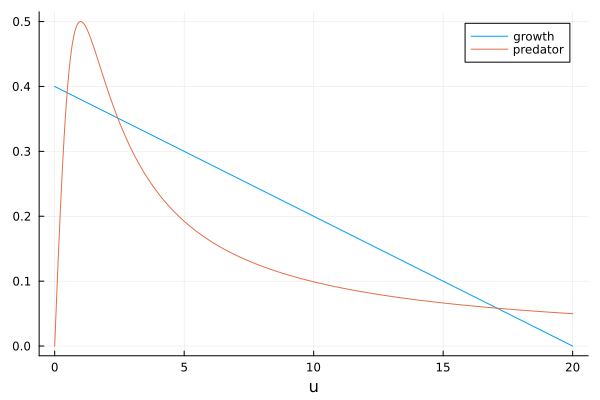

In [51]:
display(steady)

We observe that as $r$ increases from 0.4 to 0.5 while $q=20$ remains fixed, that the two steady states become close and closer to each other and then disappear.  As $r$ increases, we get a catastropic outbreak of the worm population.

Image now that we would start at $r=0.6$, at a large steady state.  
The return to a smaller value of the population will only be possible when the large steady state, jointly with the unstable middle steady state disappears as the predator line sinks below the growth line.

The catastrophic jumps happen at different values of the parameter $r$ and are depending on the direction of the parameter change.  This is called *hysteresis*.